<a href="https://colab.research.google.com/github/wooihaw/k-youth-2603/blob/main/Lab_2/Lab_2c.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lab 2c

#### Description  
The Glass Identification Dataset, used for machine learning classification, comprises 214 samples from the U.S. Forensic Science Service. It consists of nine features, including refractive index and various oxides, to classify glass into seven types. This dataset is valuable in forensic science for glass type identification based on chemical composition.

#### Tasks  
1. Print the first 5 rows of the dataset.
2. Check for missing values.
3. If there are any missing values, handle them appropriately (skip this step if there is no missing value).
4. Separate the dataset to features (X) and targets (y).
5. Split into training (80%) and testing (20%) sets using stratified hold-out validation.
6. Use stratified 3-fold cross validation on the trainig set to validate k-Nearest Neighbours, Logistric Regression, and Support Vector Machine models with the default hyperparameter values.
7. Evaluate the best model from Step (6) using the testing set.
8. Print the classification report for the best model.
9. Scale the features using StandardScaler().
10. Repeat Step (6), (7) and (8) on the scaled features.

In [1]:
# Initialization
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load libraries
from pandas import read_csv
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split as split
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

In [3]:
# Load the dataset into Pandas DataFrame
df = read_csv('https://raw.githubusercontent.com/wooihaw/datasets/main/glass_data.csv')

In [4]:
# Print first 5 rows of the dataset
df.head()

,RI,Sodium,Magnesium,Aluminum,Silicon,Potassium,Calcium,Barium,Iron,Type of Glass
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [5]:
# Check for missing values
df.isna().sum()

RI               0
Sodium           0
Magnesium        0
Aluminum         0
Silicon          0
Potassium        0
Calcium          0
Barium           0
Iron             0
Type of Glass    0
dtype: int64

In [6]:
df.describe()

,RI,Sodium,Magnesium,Aluminum,Silicon,Potassium,Calcium,Barium,Iron,Type of Glass
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [8]:
# Separate into features and target
X = df.drop(columns=['Type of Glass'])
y = df['Type of Glass']

In [9]:
# Split to training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = split(X, y, stratify=y, train_size=0.8, random_state=42)

In [10]:
# Evaluate knn, lgr, svm using stratified 3-fold cross validation
models = {}
models['knn'] = KNeighborsClassifier()
models['lgr'] = LogisticRegression()
models['svc'] = SVC()

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for n in models:
    scores = cross_val_score(models[n], X_train, y_train, cv=skf, n_jobs=-1)
    print(f'{n}: {scores.mean():.3%} +/- {scores.std():.3%}')


knn: 63.158% +/- 7.580%
lgr: 59.064% +/- 3.605%
svc: 35.673% +/- 0.827%


In [11]:
# Train and evaluate best performing model
best_model1 = KNeighborsClassifier().fit(X_train, y_train)
print(f'Best model 1 score: {best_model1.score(X_test, y_test):.3%}')

Best model 1 score: 67.442%


In [12]:
# Print classification report for the best model
y_pred = best_model1.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.63      0.86      0.73        14
           2       0.75      0.60      0.67        15
           3       0.00      0.00      0.00         3
           5       0.67      0.67      0.67         3
           6       1.00      0.50      0.67         2
           7       0.71      0.83      0.77         6

    accuracy                           0.67        43
   macro avg       0.63      0.58      0.58        43
weighted avg       0.66      0.67      0.65        43



In [13]:
# Perform feature scaling using StandardScaler
scl = StandardScaler()
Xs_train = scl.fit_transform(X_train)
Xs_test = scl.transform(X_test)

In [14]:
# Evaluate knn, lgr and svc using the scaled features
for n in models:
    scores = cross_val_score(models[n], Xs_train, y_train, cv=skf, n_jobs=-1)
    print(f'{n}: {scores.mean():.3%} +/- {scores.std():.3%}')

knn: 62.573% +/- 8.145%
lgr: 59.064% +/- 8.393%
svc: 67.836% +/- 2.188%


In [15]:
# Train and evaluate the best model 
best_model2 = SVC().fit(Xs_train, y_train)
print(f'Best model 2 score: {best_model2.score(Xs_test, y_test):.3%}')

Best model 2 score: 72.093%


In [16]:
# Print classification report for best model 2
y_pred2 = best_model2.predict(Xs_test)
print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

           1       0.69      0.79      0.73        14
           2       0.69      0.73      0.71        15
           3       0.00      0.00      0.00         3
           5       1.00      0.67      0.80         3
           6       0.50      0.50      0.50         2
           7       0.86      1.00      0.92         6

    accuracy                           0.72        43
   macro avg       0.62      0.61      0.61        43
weighted avg       0.68      0.72      0.69        43



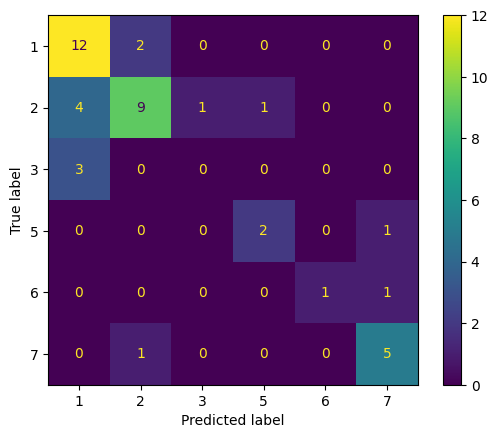

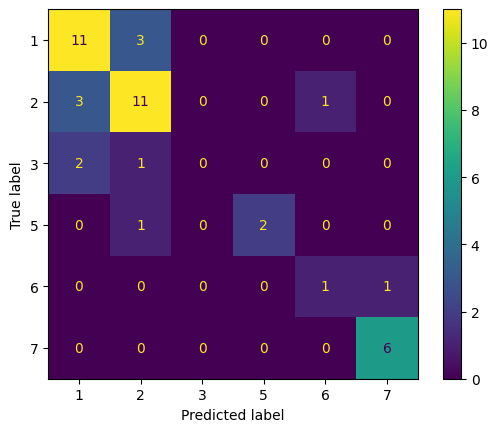

In [17]:
# Display confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred2)